# Supply Chain Analytics Project
## 1.1 Data Loading

This notebook loads the raw datasets from the Brazilian E-Commerce dataset and prepares them for cleaning and analysis.

Dataset source: Kaggle - Brazilian E-Commerce Public Dataset

In [189]:
#Importing the main libraries to use

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#Defining the data path
Because our notebook is inside notebooks, we must go one level up to reach the data folder.

In [191]:
data_path = "../data/raw/"

In [192]:
#Loading the main tables

orders = pd.read_csv(data_path + "olist_orders_dataset.csv")
order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv")
customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
products = pd.read_csv(data_path + "olist_products_dataset.csv")
sellers = pd.read_csv(data_path + "olist_sellers_dataset.csv")
payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")

## 1.2 Dataset Dimensions
In this section we examine the size of each dataset to understand how much information each table contains. This helps identify the central tables in the supply chain dataset.

In [193]:
# -----------------------------------------------------
# Dataset dimensions (rows, columns)
# -----------------------------------------------------

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Payments: (103886, 5)
Reviews: (99224, 7)


### Observations

- The **orders dataset** contains around 100k transactions and forms the central table.
- The **order_items dataset** is larger, indicating that orders may contain multiple products.
- The **products dataset** represents the product catalog.
- The **sellers dataset** contains supplier information.

This confirms that `orders` and `order_items` will be the primary tables for supply chain analysis.

## 1.1 Inspect Dataset Structure

In this section we examine the structure of each dataset including number of rows, columns, and data types. This  helps us understand how the supply chain tables relate before performing cleaning and transformations.

In [194]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [195]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [196]:
order_items.head()
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


The same can be done for the other tables in this data : customers, products, sellers and so on. But, I'm skipping here for optimisation. 

# 2. Data Cleaning
## 2.1 Missing Value Analysis

Before performing analysis or modeling, it is important to checkfor missing values in the dataset. Missing values can affect calculations, visualizations, and machine learning models.In this section we identify missing values across the key supply chain tables.

In [197]:
# -----------------------------------------------------
# Function to calculate missing values
# -----------------------------------------------------

def missing_values(df):
    
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    missing_df = pd.DataFrame({
        "Missing Values": missing_count,
        "Percentage (%)": missing_percent
    })
    
    return missing_df[missing_df["Missing Values"] > 0].sort_values(
        by="Percentage (%)", ascending=False
    )

In [198]:
# -----------------------------------------------------
# Missing values in Orders dataset
# -----------------------------------------------------

missing_values(orders)

,Missing Values,Percentage (%)
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


### Observations

Some delivery-related columns contain missing values.  
This is expected because:

- Orders that were **cancelled or not yet delivered**
  may not have delivery timestamps.
- Logistics events such as carrier pickup may also
  be missing for incomplete orders.

These missing values will be handled during
feature engineering and analysis.

In [199]:
missing_values(order_items)
missing_values(customers)
missing_values(sellers)
missing_values(payments)

,Missing Values,Percentage (%)


The **order_items, customers, sellers, and payments datasets** appear to have
  little to no missing values, indicating relatively clean transactional records.

In [200]:
missing_values(products)

,Missing Values,Percentage (%)
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


### Observations
- The **products dataset** contains missing values in fields such as
  `product_category_name`, `product_name_length`, and other product attribute columns.
  These missing values likely occur because some product metadata was not recorded
  completely.

## 2.2 Duplicate Detection
In this section we check whether any duplicate records exist in the datasets. Duplicate rows can lead to incorrect calculations and misleading insights in supply chain analytics.

We will check each dataset for duplicate rows.

In [201]:
# -----------------------------------------------------
# Function to calculate duplicate rows
# -----------------------------------------------------

def check_duplicates(df):
    
    duplicate_count = df.duplicated().sum()
    
    return duplicate_count

In [202]:
# -----------------------------------------------------
# Check duplicates across all datasets
# -----------------------------------------------------

check_duplicates(orders)
check_duplicates(products)
check_duplicates(order_items)
check_duplicates(customers)
check_duplicates(payments)
check_duplicates(reviews)
check_duplicates(sellers)


np.int64(0)

### Observations

Duplicate checks were performed across all datasets.

No duplicate rows were detected in the core supply chain tables.This indicates that the datasets are well-structured and suitable for further analysis without requiring duplicate removal.
Ensuring the absence of duplicate records is important because duplicate transactions can distort demand analysis, revenue calculations, and logistics performance metrics.

## 2.3 Date & Time Conversion
Several columns in the orders dataset represent timestamps such as order purchase time and delivery time. These columns are currently stored as strings and need to be converted to datetime format for
time-based analysis.
Converting these columns will allow us to analyze order trends,
delivery performance, and seasonal demand patterns.

In [203]:
# -----------------------------------------------------
# Identify date columns in the orders dataset
# -----------------------------------------------------

orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [204]:
# -----------------------------------------------------
# Convert order timestamp columns to datetime
# -----------------------------------------------------

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [205]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


### Observations

All order-related timestamp columns have been successfully converted
to datetime format. This allows us to perform time-based calculations
such as delivery duration, order trends over time, and logistics
performance analysis.

# 3. Feature Engineering

Feature engineering involves creating new variables from existing data that can provide meaningful insights.

In supply chain analytics, time-based features are particularly important for evaluating logistics performance and customer experience.
In this section we create variables related to delivery duration and logistics timelines.

## 3.1 Delivery Duration
Delivery duration represents the number of days between when an order was placed and when it was delivered to the customer.
This metric helps evaluate logistics efficiency and delivery
performance.

In [206]:
# -----------------------------------------------------
# Calculate delivery duration
# -----------------------------------------------------

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] 
    - orders["order_purchase_timestamp"]
).dt.days

In [207]:
orders[["order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days"]].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


### Observations

The delivery_days variable captures the total time taken for an order to reach the customer.
This metric will later help analyze logistics efficiency,identify delivery delays, and understand overall supply chain performance.

## 3.2 Delivery Delay
Delivery delay measures the difference between the actual delivery date and the estimated delivery date provided to the customer.
A positive value indicates that the order was delivered later than expected, while a negative value indicates early delivery.
This metric helps evaluate logistics performance and customer service reliability.

In [208]:
# -----------------------------------------------------
# Calculate delivery delay
# -----------------------------------------------------

orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [209]:
orders[[
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delay_days"
]].head()

,order_delivered_customer_date,order_estimated_delivery_date,delay_days
0,2017-10-10 21:25:13,2017-10-18,-8.0
1,2018-08-07 15:27:45,2018-08-13,-6.0
2,2018-08-17 18:06:29,2018-09-04,-18.0
3,2017-12-02 00:28:42,2017-12-15,-13.0
4,2018-02-16 18:17:02,2018-02-26,-10.0


### Observations

The delay_days feature measures whether deliveries occurred earlier or later than the estimated delivery date.
Negative values indicate early delivery, while positive values represent delayed deliveries.
This feature will help analyze logistics performance and identify potential delivery bottlenecks in the supply chain.

## 3.3 Order Processing Time
Order processing time represents the duration between when a customer places an order and when the order is approved by the system.
This metric helps evaluate internal order processing efficiency.

In [210]:
# -----------------------------------------------------
# Calculate order processing time
# -----------------------------------------------------

orders["processing_days"] = (
    orders["order_approved_at"]
    - orders["order_purchase_timestamp"]
).dt.days

In [211]:
orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "processing_days"
]].head()

,order_purchase_timestamp,order_approved_at,processing_days
0,2017-10-02 10:56:33,2017-10-02 11:07:15,0.0
1,2018-07-24 20:41:37,2018-07-26 03:24:27,1.0
2,2018-08-08 08:38:49,2018-08-08 08:55:23,0.0
3,2017-11-18 19:28:06,2017-11-18 19:45:59,0.0
4,2018-02-13 21:18:39,2018-02-13 22:20:29,0.0


## 3.4 Carrier Handling Time
Carrier handling time measures how long it takes for the logistics carrier to pick up the package after the order
has been approved.
This metric reflects warehouse and fulfillment efficiency.

In [212]:
# -----------------------------------------------------
# Carrier pickup delay
# -----------------------------------------------------

orders["carrier_wait_days"] = (
    orders["order_delivered_carrier_date"]
    - orders["order_approved_at"]
).dt.days

orders[[
    "order_approved_at",
    "order_delivered_carrier_date",
    "carrier_wait_days"
]].head()

,order_approved_at,order_delivered_carrier_date,carrier_wait_days
0,2017-10-02 11:07:15,2017-10-04 19:55:00,2.0
1,2018-07-26 03:24:27,2018-07-26 14:31:00,0.0
2,2018-08-08 08:55:23,2018-08-08 13:50:00,0.0
3,2017-11-18 19:45:59,2017-11-22 13:39:59,3.0
4,2018-02-13 22:20:29,2018-02-14 19:46:34,0.0


## 3.5 Shipping Time
Shipping time measures the duration between when the carrier picks up the package and when it is delivered to the customer.
This metric represents transportation efficiency in the supply chain.

In [213]:
# -----------------------------------------------------
# Calculate shipping duration
# -----------------------------------------------------

orders["shipping_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_delivered_carrier_date"]
).dt.days

orders[[
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_days"
]].head()

,order_delivered_carrier_date,order_delivered_customer_date,shipping_days
0,2017-10-04 19:55:00,2017-10-10 21:25:13,6.0
1,2018-07-26 14:31:00,2018-08-07 15:27:45,12.0
2,2018-08-08 13:50:00,2018-08-17 18:06:29,9.0
3,2017-11-22 13:39:59,2017-12-02 00:28:42,9.0
4,2018-02-14 19:46:34,2018-02-16 18:17:02,1.0


## 3.6 Late Delivery Indicator
A late delivery indicator is created to identify whether an order was delivered later than the estimated delivery date.
This binary variable will help measure the percentage of late deliveries in the supply chain.

In [214]:
# -----------------------------------------------------
# Create late delivery flag
# -----------------------------------------------------

orders["late_delivery"] = (orders["delay_days"] > 0).astype(int)
orders[[
    "delay_days",
    "late_delivery"
]].head()

,delay_days,late_delivery
0,-8.0,0
1,-6.0,0
2,-18.0,0
3,-13.0,0
4,-10.0,0


###Observations:
Values will be:
0 → On-time or early delivery
1 → Late delivery

4. Other important checks and conversions

In [215]:
#Convert Product Category to Category Type (Optimization)
# -----------------------------------------------------
# Convert product category to categorical type
# -----------------------------------------------------

products["product_category_name"] = products["product_category_name"].astype("category")

In [216]:
#Convert Order Status to Category
# -----------------------------------------------------
# Convert order status to category
# -----------------------------------------------------

orders["order_status"] = orders["order_status"].astype("category")

In [217]:
# -----------------------------------------------------
# Extract order time features
# -----------------------------------------------------

orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_dayofweek"] = orders["order_purchase_timestamp"].dt.day_name()

## 4.1 Outlier Detection
Before performing exploratory analysis, it is important to check for outliers in key numerical variables.
Outliers may represent unusual logistics cases such as extremely delayed deliveries or data entry errors. Identifying them helps ensure that the analysis is not distorted by extreme values.

In [218]:
# -----------------------------------------------------
# Summary statistics for delivery time
# -----------------------------------------------------

orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

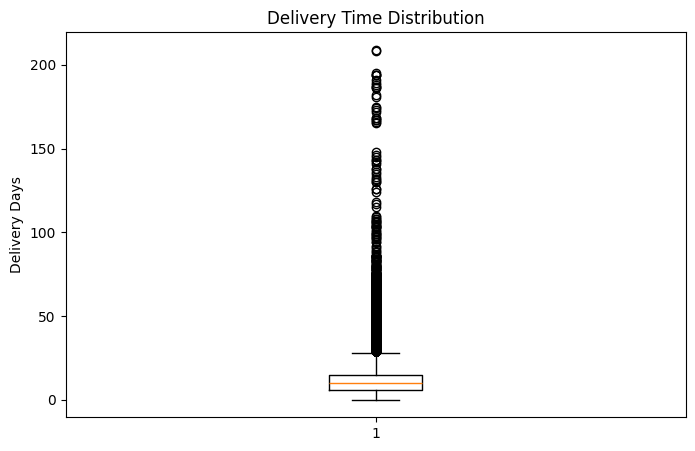

In [219]:
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Boxplot to detect outliers
# -----------------------------------------------------

plt.figure(figsize=(8,5))
plt.boxplot(orders["delivery_days"].dropna())
plt.title("Delivery Time Distribution")
plt.ylabel("Delivery Days")
plt.show()

### Observations
The boxplot helps visualize the distribution of delivery times and highlights potential outliers.
Extremely large delivery durations may represent exceptional logistics delays or data irregularities. These values will be considered carefully during analysis to ensure accurate insights.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships within the supply chain data.
In this section we analyze key performance indicators such as delivery performance, order trends, and logistics efficiency.

## 4.1 Average Delivery Time
This is a core logistics KPI

In [220]:
# -----------------------------------------------------
# Average delivery duration
# -----------------------------------------------------

avg_delivery = orders["delivery_days"].mean()

print("Average Delivery Time:", round(avg_delivery,2), "days")

Average Delivery Time: 12.09 days


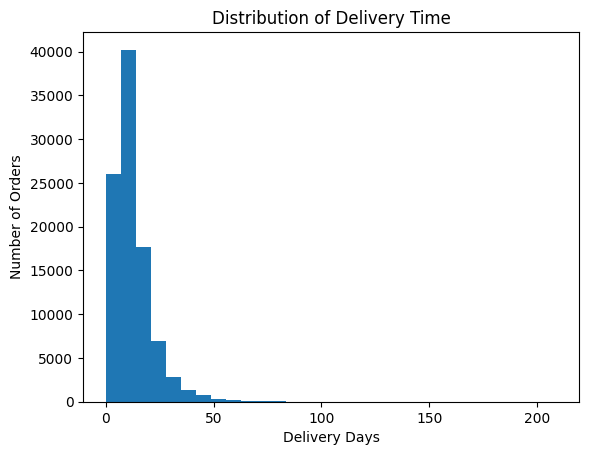

In [221]:
import matplotlib.pyplot as plt

plt.hist(orders["delivery_days"].dropna(), bins=30)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

### Observations

The average delivery time represents the typical number of days required for an order to reach the customer after purchase.Understanding this metric helps evaluate overall logistics performance and customer service efficiency.

## 4.2 Late Delivery Rate
This is a very important supply chain KPI.

In [222]:
# -----------------------------------------------------
# Percentage of late deliveries
# -----------------------------------------------------

late_rate = orders["late_delivery"].mean() * 100

print("Late Delivery Rate:", round(late_rate,2), "%")

Late Delivery Rate: 6.57 %


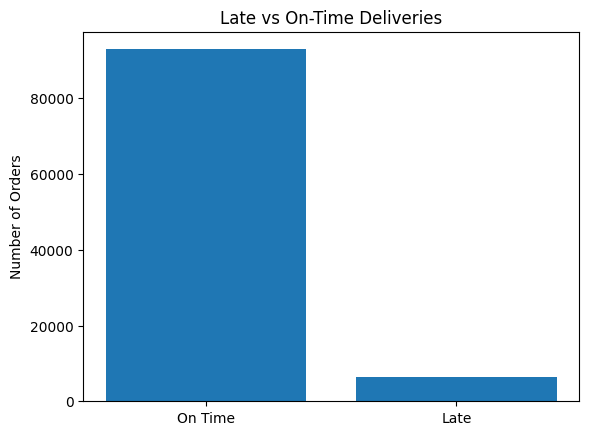

In [223]:
late_counts = orders["late_delivery"].value_counts()

plt.bar(["On Time","Late"], late_counts)
plt.title("Late vs On-Time Deliveries")
plt.ylabel("Number of Orders")
plt.show()

In [224]:
# -----------------------------------------------------
# Create Monthly Orders Dataset
# -----------------------------------------------------

monthly_orders = (
    orders
    .groupby("order_month")
    .size()
    .reset_index(name="order_count")
)

monthly_orders.head()

monthly_orders = monthly_orders.rename(columns={
    "order_month": "date"
})

monthly_orders = monthly_orders.sort_values("date")

monthly_orders.head()

,date,order_count
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573


### Observations

The late delivery rate measures the proportion of orders that arrived later than the estimated delivery date.
A high late delivery rate may indicate inefficiencies in the logistics network or delays in transportation.

## 4.3 Order Volume Trends
This shows business growth and seasonality.(Demand analysis)

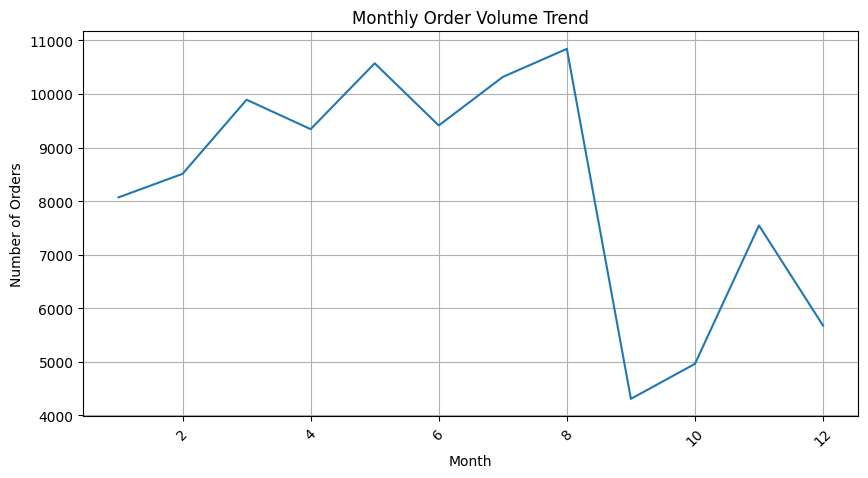

In [225]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders["date"],
    monthly_orders["order_count"]
)

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observations

The order volume trend highlights fluctuations in customer demand over time. Variations in monthly orders may reflect seasonal purchasing behavior, marketing campaigns, or overall business growth.
Analyzing demand trends is essential for supply chain planning, as it enables organizations to forecast inventory requirements, optimize warehouse operations, and allocate logistics resources effectively during high-demand periods.

## 4.2 Revenue Analysis
Now we merge orders + payments.

In [226]:
# -----------------------------------------------------
# Merge orders and payments
# -----------------------------------------------------

revenue_df = orders.merge(
    payments,
    on="order_id",
    how="left"
)

revenue_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,processing_days,carrier_wait_days,shipping_days,late_delivery,order_year,order_month,order_dayofweek,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,0.0,2.0,6.0,0,2017,10,Monday,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,0.0,2.0,6.0,0,2017,10,Monday,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,0.0,2.0,6.0,0,2017,10,Monday,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,1.0,0.0,12.0,0,2018,7,Tuesday,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,0.0,0.0,9.0,0,2018,8,Wednesday,1.0,credit_card,3.0,179.12


In [227]:
#Calculate total revenue

total_revenue = revenue_df["payment_value"].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 16008872.12


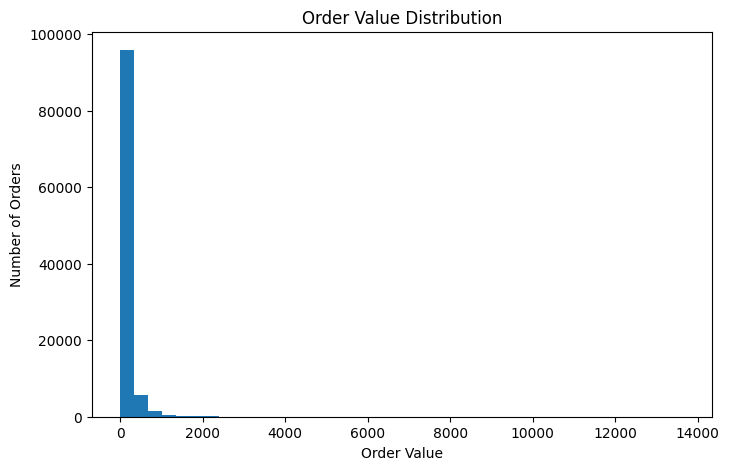

In [228]:
plt.figure(figsize=(8,5))

plt.hist(revenue_df["payment_value"], bins=40)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

### Observation
The chart suggests that there are mostly orders of values less than 2000 and almost none above 2000.

## 4.3 Delivery Performance

In [229]:
avg_delivery = orders["delivery_days"].mean()
avg_shipping = orders["shipping_days"].mean()
avg_processing = orders["processing_days"].mean()

print("Average Delivery Time:", round(avg_delivery,2))
print("Average Shipping Time:", round(avg_shipping,2))
print("Average Processing Time:", round(avg_processing,2))

Average Delivery Time: 12.09
Average Shipping Time: 8.88
Average Processing Time: 0.27


## 4.4 Logistics Bottleneck Analysis
This shows where delays happen.

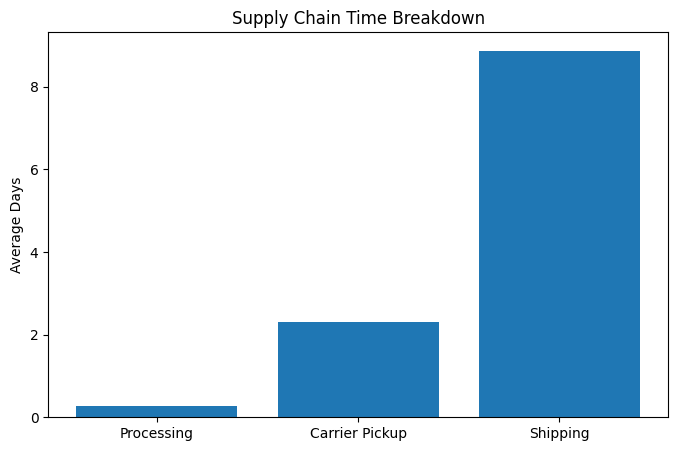

In [230]:
logistics = [
    orders["processing_days"].mean(),
    orders["carrier_wait_days"].mean(),
    orders["shipping_days"].mean()
]

labels = [
    "Processing",
    "Carrier Pickup",
    "Shipping"
]

plt.figure(figsize=(8,5))

plt.bar(labels, logistics)

plt.title("Supply Chain Time Breakdown")
plt.ylabel("Average Days")

plt.show()

### Observatiom
There is a huge gap in average days between carrier pickup and shipping. It suggests that there might be some inefficiencies in transportation of goods from DCs/Warehouses to customer points. There is a scope of improvement in that area.

## 4.5 Demand vs Late Delivery Rate Over Time
This shows whether high demand months cause more delivery delays, which is a very strong supply chain insight.

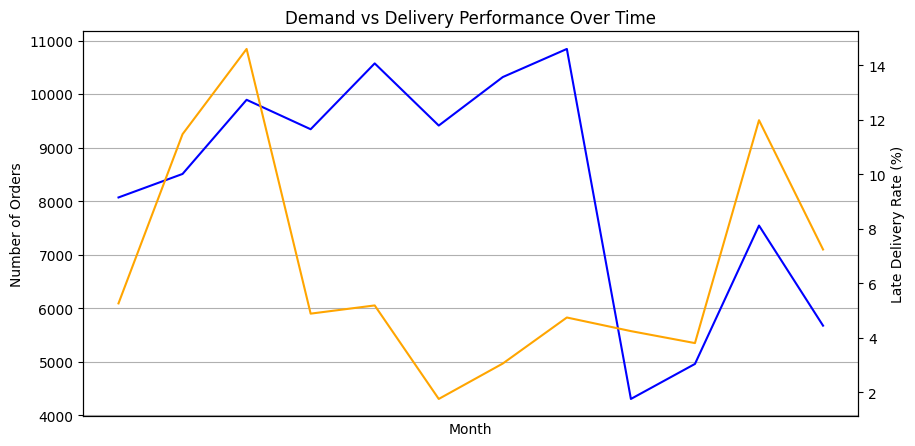

In [231]:
# -----------------------------------------------------
# Monthly Late Delivery Rate
# -----------------------------------------------------

late_monthly = orders.groupby(
    "order_month"
)["late_delivery"].mean().reset_index()

late_monthly["late_rate"] = late_monthly["late_delivery"] * 100

late_monthly = late_monthly.rename(columns={"order_month": "date"})

late_monthly = late_monthly.sort_values("date")
monthly_orders["date"] = pd.to_datetime(monthly_orders["date"])
late_monthly["date"] = pd.to_datetime(late_monthly["date"])


# -----------------------------------------------------
# Merge with Monthly Orders
# -----------------------------------------------------

trend_analysis = monthly_orders.merge(
    late_monthly[["date", "late_rate"]],
    on="date",
    how="left"
)


# -----------------------------------------------------
# Demand vs Delivery Performance (Dual Axis Chart)
# -----------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10,5))

# Orders line
ax1.plot(
    trend_analysis["date"],
    trend_analysis["order_count"],
    color="blue",
    label="Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders")

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    trend_analysis["date"],
    trend_analysis["late_rate"],
    color="orange",
    label="Late Delivery %"
)

ax2.set_ylabel("Late Delivery Rate (%)")

plt.title("Demand vs Delivery Performance Over Time")

ax1.grid(True)

plt.xticks(rotation=45)

plt.show()

### Observations

The chart compares monthly order demand with the late delivery rate. This helps evaluate whether increases in order volume place additional pressure on the logistics network.
Periods with high demand may coincide with higher late delivery rates, suggesting that logistics capacity could be strained during peak demand periods.
Understanding this relationship helps organizations plan warehouse capacity, transportation resources, and staffing levels during high-demand months.

## 4.6 Product & Category Performance

This analysis evaluates product demand across different product categories to identify high-performing segments and understand customer purchasing preferences.

In [232]:
# -----------------------------------------------------
# Merge order items with product information
# -----------------------------------------------------

product_data = order_items.merge(
    products,
    on="product_id",
    how="left"
)
# -----------------------------------------------------
# Top categories by number of items sold
# -----------------------------------------------------

top_categories = product_data.groupby(
    "product_category_name"
)["order_item_id"].count().sort_values(ascending=False).head(10)

top_categories

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: order_item_id, dtype: int64

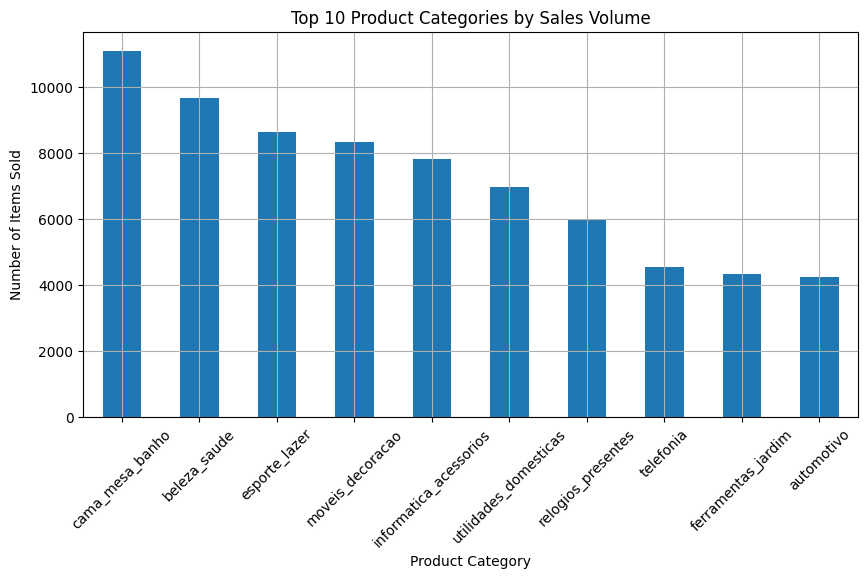

In [233]:
plt.figure(figsize=(10,5))

top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories by Sales Volume")
plt.xlabel("Product Category")
plt.ylabel("Number of Items Sold")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observations

The analysis highlights the most popular product categories based on total items sold. High-performing categories indicate areas where customer demand is strongest.
These insights help businesses prioritize inventory planning,supplier partnerships, and marketing investments for
high-demand product segments.

## 4.7 Seller Performance

This section evaluates seller performance based on the number of orders fulfilled. Identifying high-performing sellers helps understand supply network strength and marketplace dependency
on key vendors.

In [234]:
# -----------------------------------------------------
# Top sellers by order volume
# -----------------------------------------------------

top_sellers = order_items.groupby(
    "seller_id"
)["order_id"].count().sort_values(ascending=False).head(10)

top_sellers

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: order_id, dtype: int64

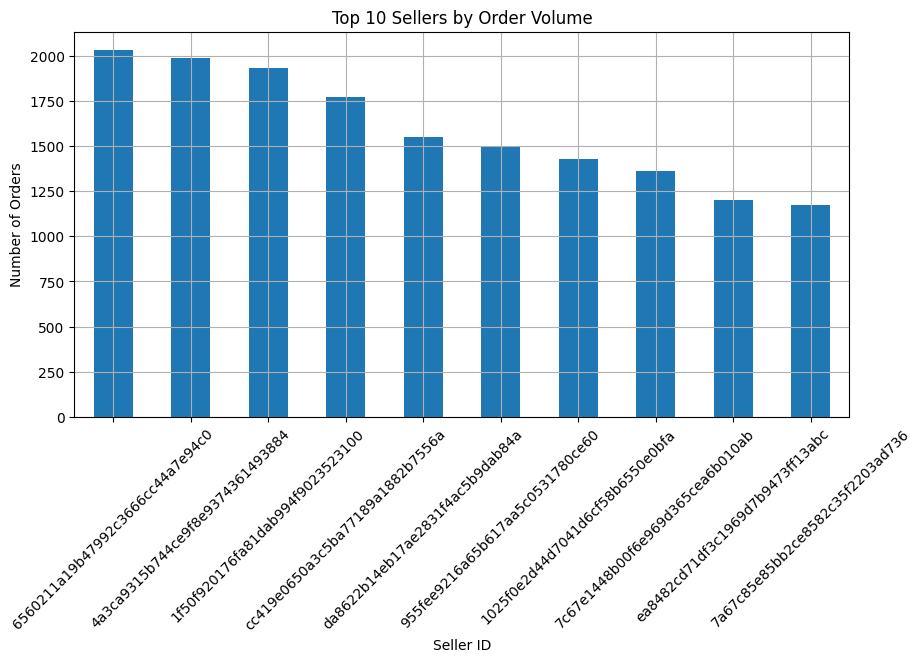

In [235]:
plt.figure(figsize=(10,5))

top_sellers.plot(kind="bar")

plt.title("Top 10 Sellers by Order Volume")
plt.xlabel("Seller ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observations

The seller performance analysis reveals the distribution of order fulfillment across marketplace sellers. A small group of sellers often contributes a significant portion of total orders, indicating potential reliance on key suppliers.
Understanding seller performance helps organizations evaluate supplier risk and identify opportunities to diversify the seller network.

## 4.7 Geographic Demand Analysis

This analysis examines customer demand across different geographic regions. Understanding geographic distribution
of orders helps optimize warehouse placement, logistics planning, and regional inventory allocation.

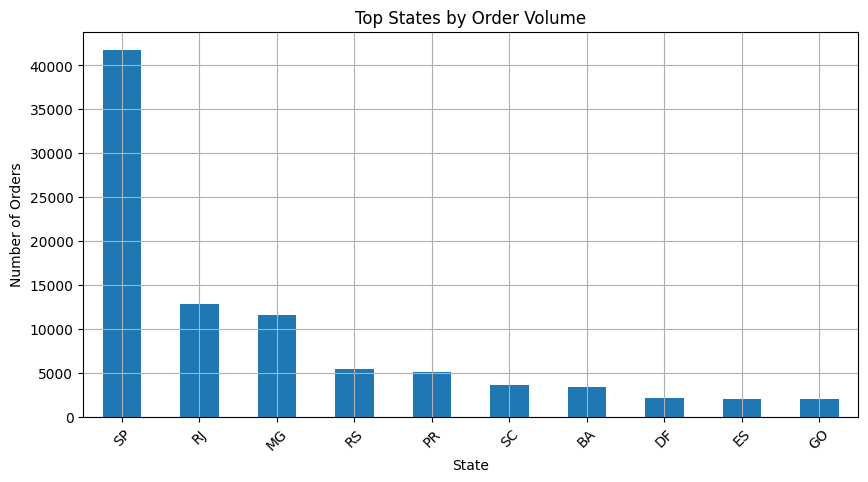

In [236]:
# -----------------------------------------------------
# Merge orders with customer location
# -----------------------------------------------------

geo_data = orders.merge(
    customers,
    on="customer_id",
    how="left"
)
state_orders = geo_data.groupby(
    "customer_state"
)["order_id"].count().sort_values(ascending=False).head(10)

state_orders
plt.figure(figsize=(10,5))

state_orders.plot(kind="bar")

plt.title("Top States by Order Volume")
plt.xlabel("State")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observations

Geographic demand analysis reveals which regions generate the highest order volumes. Concentrated demand in certain
states may indicate strong market presence or higher population density.

These insights support supply chain decisions such as regional warehouse placement, delivery network design,
and targeted marketing strategies.

## 4.8 Demand seasonality Analysis
Instead of just trend, check seasonal patterns.

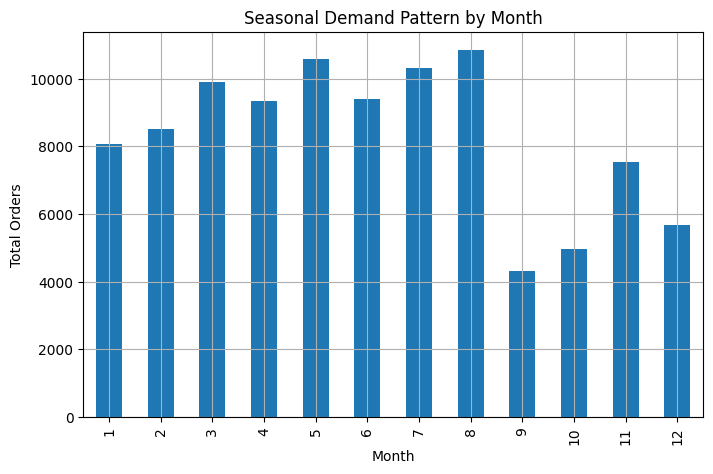

In [237]:
seasonality = orders.groupby("order_month")["order_id"].count()

seasonality

plt.figure(figsize=(8,5))

seasonality.plot(kind="bar")

plt.title("Seasonal Demand Pattern by Month")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.grid(True)

plt.show()

## 4.9 Seller Delivery Performance
This analysis evaluates seller reliability by measuring the percentage of orders delivered late for each seller. Identifying sellers with higher delay rates helps detect potential supplier risk within the supply chain network.

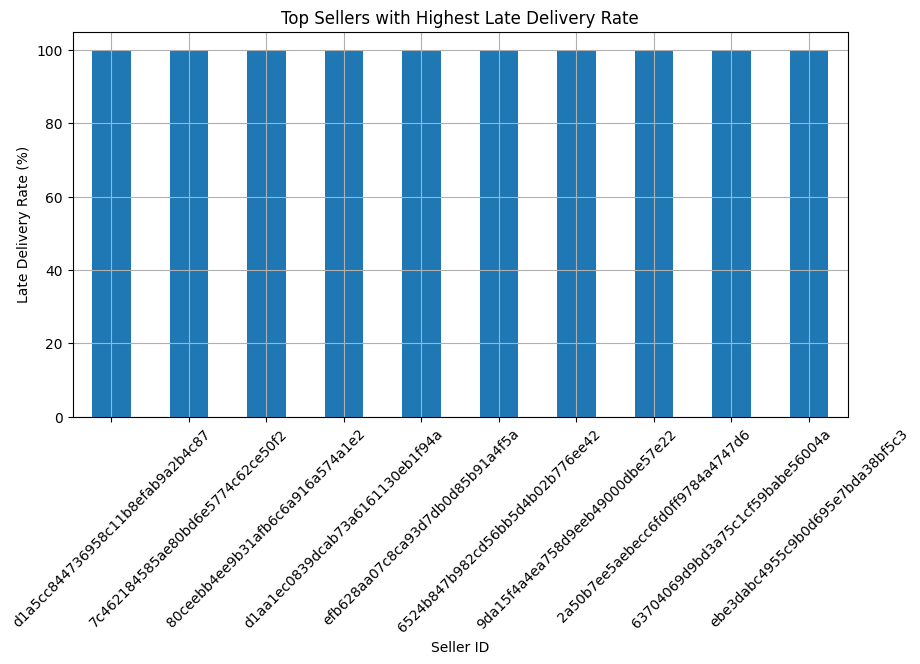

In [238]:
# -----------------------------------------------------
# Merge seller information with order delivery status
# -----------------------------------------------------

seller_orders = order_items.merge(
    orders[["order_id", "late_delivery"]],
    on="order_id",
    how="left"
)
# -----------------------------------------------------
# Late delivery rate per seller
# -----------------------------------------------------

seller_delay_rate = seller_orders.groupby("seller_id")["late_delivery"].mean()

seller_delay_rate = seller_delay_rate.sort_values(ascending=False).head(10)

seller_delay_rate = seller_delay_rate * 100

seller_delay_rate

plt.figure(figsize=(10,5))

seller_delay_rate.plot(kind="bar")

plt.title("Top Sellers with Highest Late Delivery Rate")
plt.xlabel("Seller ID")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()


### Observations

The seller delivery performance analysis highlights sellers with higher late delivery rates. These sellers may represent potential supply chain risks due to slower fulfillment or shipping delays.
Monitoring seller reliability is important for marketplace platforms to ensure consistent delivery performance and maintain customer satisfaction.

5.0 Customer Purchase Behavior
This analysis evaluates customer purchasing patterns by examining how frequently customers place orders. Understanding the proportion of repeat customers helps businesses assess customer loyalty and marketplace retention performance.

In [239]:
# -----------------------------------------------------
# Merge orders with customers to get unique customer ID
# -----------------------------------------------------

orders_customers = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)   
# Count number of orders per real customer
# -----------------------------------------------------

customer_orders = orders_customers.groupby(
    "customer_unique_id"
)["order_id"].count()

customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [240]:
# -----------------------------------------------------
# Classify customers based on purchase frequency
# -----------------------------------------------------

one_time_buyers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

customer_segments = {
    "One-time buyers": one_time_buyers,
    "Repeat customers": repeat_customers
}

customer_segments

{'One-time buyers': np.int64(93099), 'Repeat customers': np.int64(2997)}

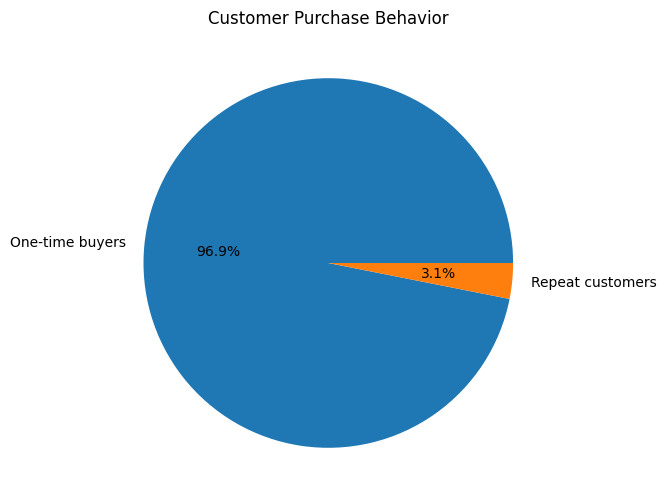

In [241]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_segments.values(),
    labels=customer_segments.keys(),
    autopct="%1.1f%%"
)

plt.title("Customer Purchase Behavior")

plt.show()

## Observations

The analysis shows that the majority of customers place only a single order, while a smaller segment consists of repeat buyers. This indicates an opportunity for improving customer retention through loyalty programs and personalized marketing strategies.

EDA Summary Section

Key Insights from Exploratory Data Analysis
1. Order demand shows steady growth over time with clear fluctuations across months, indicating possible seasonal demand patterns.

2. Certain product categories dominate sales volume, suggesting concentrated customer demand within specific segments.

3. A small group of sellers fulfills a significant portion of orders, highlighting dependency on key suppliers within the marketplace.

4. Demand is geographically concentrated in a few states and cities, indicating regional demand clusters.

5. Delivery delays increase slightly during higher order volumes, suggesting potential logistics capacity constraints during peak periods.

6. Most customers place only a single order, indicating that customer retention could be improved through loyalty program or targeted marketing strategies.

Demand Forecasting

## 6 Demand Forecasting

In this section, we build a machine learning model to predict future order demand using historical order data. Accurate demand forecasts help supply chain teams plan inventory levels, warehouse capacity, and logistics operations more effectively. 

### 6.1 Preparing the Forecasting Dataset

To perform demand forecasting, we first create a time-series dataset
that aggregates total order volume at a monthly level.

In [242]:
# -----------------------------------------------------
# Monthly demand dataset
# -----------------------------------------------------

monthly_orders = orders.groupby(
    ["order_year", "order_month"]
)["order_id"].count().reset_index()

monthly_orders.rename(columns={"order_id": "order_count"}, inplace=True)

monthly_orders.head()

,order_year,order_month,order_count
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780


### 6.2 Creating Time Index

We convert the year and month columns into a proper datetime format
so that the dataset can be treated as a time series.

In [243]:
# -----------------------------------------------------
# Create date column
# -----------------------------------------------------

monthly_orders["date"] = pd.to_datetime(
    monthly_orders["order_year"].astype(str) + "-" +
    monthly_orders["order_month"].astype(str)
)

monthly_orders = monthly_orders.sort_values("date")

monthly_orders.head()

,order_year,order_month,order_count,date
0,2016,9,4,2016-09-01
1,2016,10,324,2016-10-01
2,2016,12,1,2016-12-01
3,2017,1,800,2017-01-01
4,2017,2,1780,2017-02-01


### 6.3 Feature Engineering for Forecasting

To improve forecasting performance, we create lag features that represent demand from previous months. These features allow the model to learn temporal patterns in order volume.

In [244]:
# -----------------------------------------------------
# Remove incomplete months
# -----------------------------------------------------

monthly_orders = monthly_orders[monthly_orders["order_count"] > 100]

In [245]:
# -----------------------------------------------------
# Lag features
# -----------------------------------------------------

monthly_orders["lag_1"] = monthly_orders["order_count"].shift(1)
monthly_orders["lag_2"] = monthly_orders["order_count"].shift(2)
monthly_orders["lag_3"] = monthly_orders["order_count"].shift(3)

monthly_orders.head()

,order_year,order_month,order_count,date,lag_1,lag_2,lag_3
1,2016,10,324,2016-10-01,NaN,NaN,NaN
3,2017,1,800,2017-01-01,324.0,NaN,NaN
4,2017,2,1780,2017-02-01,800.0,324.0,NaN
5,2017,3,2682,2017-03-01,1780.0,800.0,324.0
6,2017,4,2404,2017-04-01,2682.0,1780.0,800.0


### 6.4 Rolling Average Demand

Rolling averages help smooth short-term fluctuations and provide
the model with information about recent demand trends.

In [246]:
# -----------------------------------------------------
# Correct rolling average feature (no leakage)
# -----------------------------------------------------

monthly_orders["rolling_mean_3"] = (
    monthly_orders["order_count"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_orders.head()

,order_year,order_month,order_count,date,lag_1,lag_2,lag_3,rolling_mean_3
1,2016,10,324,2016-10-01,NaN,NaN,NaN,NaN
3,2017,1,800,2017-01-01,324.0,NaN,NaN,NaN
4,2017,2,1780,2017-02-01,800.0,324.0,NaN,NaN
5,2017,3,2682,2017-03-01,1780.0,800.0,324.0,968.0
6,2017,4,2404,2017-04-01,2682.0,1780.0,800.0,1754.0


In [247]:
# -----------------------------------------------------
# Remove rows with missing values
# -----------------------------------------------------

monthly_orders = monthly_orders.dropna()

monthly_orders.head()

,order_year,order_month,order_count,date,lag_1,lag_2,lag_3,rolling_mean_3
5,2017,3,2682,2017-03-01,1780.0,800.0,324.0,968.000000
6,2017,4,2404,2017-04-01,2682.0,1780.0,800.0,1754.000000
7,2017,5,3700,2017-05-01,2404.0,2682.0,1780.0,2288.666667
8,2017,6,3245,2017-06-01,3700.0,2404.0,2682.0,2928.666667
9,2017,7,4026,2017-07-01,3245.0,3700.0,2404.0,3116.333333


Train–Test Split

### 6.6 Train-Test Split

Since this is a time-series forecasting problem, we cannot randomly shuffle the dataset. Instead, we split the data chronologically so that the model is trained on past observations and tested on future data.

### Feature and Target Variables

The model uses lagged demand and rolling averages as features to predict future monthly order demand.

In [248]:
# -----------------------------------------------------
# Train-test split for time series
# -----------------------------------------------------

train_size = int(len(monthly_orders) * 0.8)

train = monthly_orders.iloc[:train_size]
test = monthly_orders.iloc[train_size:]

print(train.shape)
print(test.shape)

(14, 8)
(4, 8)


In [249]:
features = ["lag_1", "lag_2", "lag_3", "rolling_mean_3"]

X_train = train[features]
y_train = train["order_count"]

X_test = test[features]
y_test = test["order_count"]

Linear Regression Model (Baseline Model)

### 6.7 Linear Regression Model

We first train a Linear Regression model as a baseline forecasting model. This allows us to evaluate whether
more complex models provide improved prediction accuracy.

In [250]:
from sklearn.linear_model import LinearRegression

# -----------------------------------------------------
# Train Linear Regression model
# -----------------------------------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [251]:
# -----------------------------------------------------
# Predict demand on test data
# -----------------------------------------------------

lr_predictions = lr_model.predict(X_test)

lr_predictions[:5]

array([7517.11154396, 7505.88912662, 7392.89951768, 6989.45656372])

### 6.8 Model Evaluation

We evaluate model performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which measure the
difference between predicted demand and actual demand.

In [252]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------------------------------
# Evaluate model performance
# -----------------------------------------------------

mae = mean_absolute_error(y_test, lr_predictions)

rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 890.3391879960639
RMSE: 954.914694190217


Forecast vs Actual Visualization
### Forecast vs Actual Demand

In [253]:
# -----------------------------------------------------
# Create comparison dataframe
# -----------------------------------------------------

forecast_results = test[["date", "order_count"]].copy()

forecast_results["predicted_orders"] = lr_predictions

forecast_results.head()

,date,order_count,predicted_orders
19,2018-05-01,6873,7517.111544
20,2018-06-01,6167,7505.889127
21,2018-07-01,6292,7392.899518
22,2018-08-01,6512,6989.456564


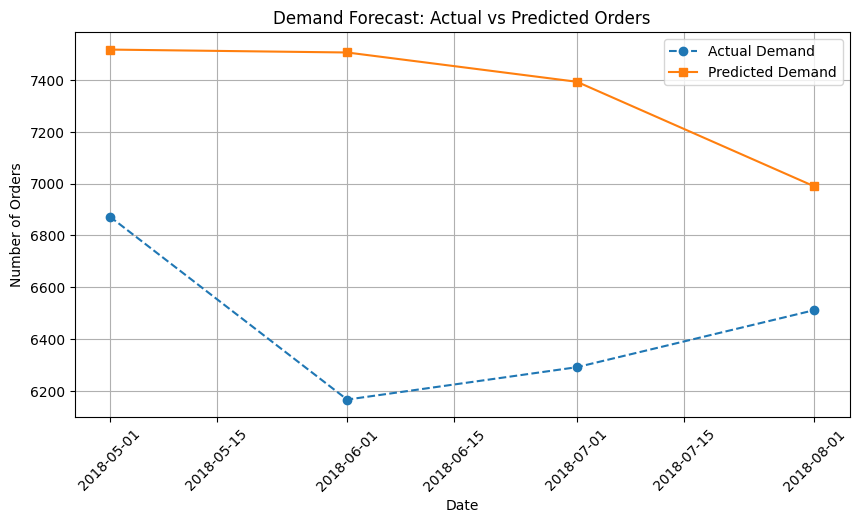

In [254]:

plt.figure(figsize=(10,5))

plt.plot(
    forecast_results["date"],
    forecast_results["order_count"],
    marker="o",
    linestyle="--",
    label="Actual Demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["predicted_orders"],
    marker="s",
    label="Predicted Demand"
)

plt.title("Demand Forecast: Actual vs Predicted Orders")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

In [255]:
len(test)

4

Important Insight
The final months in the dataset contained incomplete order records, which caused artificially low demand values. These months were removed to ensure accurate model training and evaluation.


### Observations

The Linear Regression model captures the general demand pattern but tends to slightly overestimate order volume in the test period. This occurs because earlier months in the dataset exhibit higher order volumes, influencing the model's predictions.
While the model provides a reasonable baseline forecast, more advanced models such as Random Forest or Gradient Boosting may improve prediction accuracy by capturing more complex demand patterns.

## 6.1 Random Forest Regression Model
Random Forest is an ensemble machine learning model that combines multiple decision trees to improve prediction accuracy.
Unlike Linear Regression, Random Forest can capture non-linear relationships between features and demand, making it well suited for demand forecasting problems in supply chain analytics.

In [256]:
# -----------------------------------------------------
# Train Random Forest Model
# -----------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [257]:
# -----------------------------------------------------
# Generate Predictions using Random Forest
# -----------------------------------------------------

rf_predictions = rf_model.predict(X_test)

rf_predictions

array([7002.44 , 6985.54 , 7074.63 , 7053.755])

In [258]:
# -----------------------------------------------------
# Compare Actual vs LR vs Random Forest
# -----------------------------------------------------

forecast_results = test[["date", "order_count"]].copy()

forecast_results["lr_predictions"] = lr_predictions
forecast_results["rf_predictions"] = rf_predictions

forecast_results

,date,order_count,lr_predictions,rf_predictions
19,2018-05-01,6873,7517.111544,7002.440
20,2018-06-01,6167,7505.889127,6985.540
21,2018-07-01,6292,7392.899518,7074.630
22,2018-08-01,6512,6989.456564,7053.755


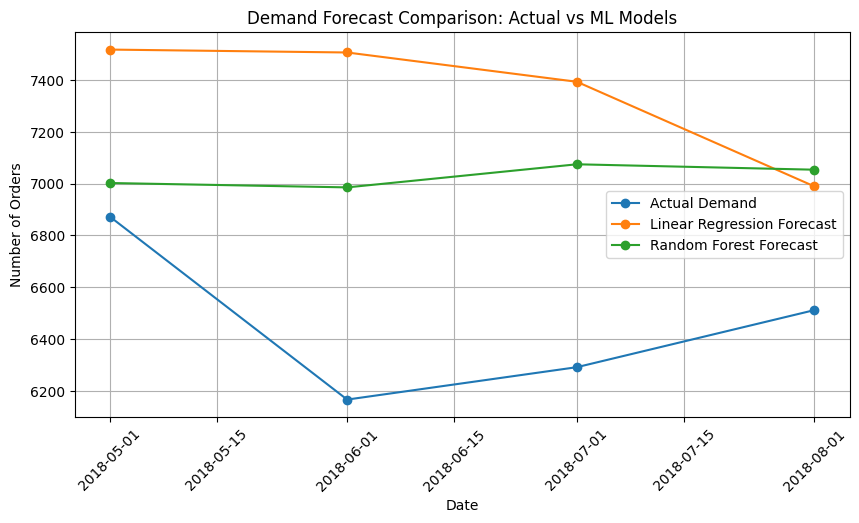

In [259]:
# -----------------------------------------------------
# Model Comparison: Actual vs LR vs Random Forest
# -----------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    forecast_results["date"],
    forecast_results["order_count"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["lr_predictions"],
    marker="o",
    label="Linear Regression Forecast"
)

plt.plot(
    forecast_results["date"],
    forecast_results["rf_predictions"],
    marker="o",
    label="Random Forest Forecast"
)

plt.title("Demand Forecast Comparison: Actual vs ML Models")

plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

## 6.2 Model Evaluation
To evaluate forecasting performance, we compare the prediction
accuracy of the Linear Regression and Random Forest models.

We use the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Lower values indicate better prediction accuracy.

In [260]:
# -----------------------------------------------------
# Model Evaluation Metrics
# -----------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error


# Linear Regression metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

print("\nRandom Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Linear Regression MAE: 890.3391879960639
Linear Regression RMSE: 954.914694190217

Random Forest MAE: 568.09125
Random Forest RMSE: 631.0250870854898


### Observations

The Random Forest model demonstrates improved forecasting accuracy compared to Linear Regression, as reflected in lower error metrics.
This suggests that Random Forest is better able to capture complex relationships in historical demand patterns, making it a more suitable model for demand forecasting in this dataset.

## 6.3 Feature Importance

To better understand the drivers of demand, we analyze feature importance from the Random Forest model. This helps identify which historical demand indicators contribute most to forecasting accuracy.

In [261]:
# -----------------------------------------------------
# Feature Importance (Random Forest)
# -----------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
0,lag_1,0.282227
2,lag_3,0.275009
3,rolling_mean_3,0.273217
1,lag_2,0.169548


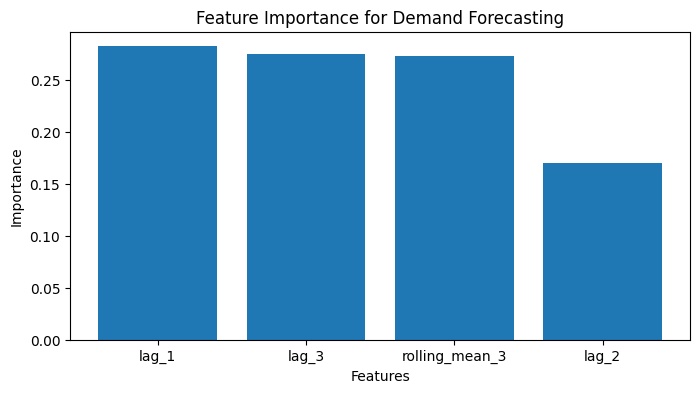

In [262]:
plt.figure(figsize=(8,4))

plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Feature Importance for Demand Forecasting")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

# 7. Inventory Optimization Analysis

Demand forecasting is only useful when it can support operational decisions.
In supply chain management, demand forecasts are commonly used to determine
optimal inventory levels.

In this section, we estimate key inventory planning metrics:

- Average Monthly Demand
- Demand Variability
- Safety Stock
- Reorder Point

These metrics help businesses reduce stockouts while avoiding excess inventory.

## 7.1 Demand Statistics
Before calculating inventory policies, we first compute basic demand statistics from historical order data.

These statistics help quantify demand variability and are used in safety stock calculations.

In [263]:
# -----------------------------------------------------
# Demand Statistics
# -----------------------------------------------------

avg_demand = monthly_orders["order_count"].mean()
std_demand = monthly_orders["order_count"].std()

print("Average Monthly Demand:", round(avg_demand))
print("Demand Standard Deviation:", round(std_demand))

Average Monthly Demand: 5362
Demand Standard Deviation: 1700


## 7.2 Safety Stock Calculation

Safety stock is the additional inventory maintained to protect against demand variability and supply delays.

A common safety stock formula is:
Safety Stock = Z × σ
Where:
- Z = Service level factor
- σ = Standard deviation of demand

For this analysis, we assume a **95% service level**, which corresponds to a Z-score of **1.65**.

In [264]:
# -----------------------------------------------------
# Safety Stock Calculation
# -----------------------------------------------------

z_score = 1.65   # 95% service level

safety_stock = z_score * std_demand

print("Safety Stock:", round(safety_stock))

Safety Stock: 2804


### Observation

Based on historical demand variability, the recommended safety stock level is approximately the calculated value above. Maintaining this buffer helps ensure that unexpected spikes in demand can be fulfilled
without causing stockouts.
Higher service levels would require maintaining larger safety stock, while lower service levels would reduce inventory holding costs.

## 7.3 Reorder Point Calculation

The Reorder Point (ROP) indicates the inventory level at which a new order should be placed to replenish stock before it runs out.
The formula used is:

Reorder Point = (Average Demand × Lead Time) + Safety Stock

Where:
- Average Demand = Average monthly order volume
- Lead Time = Time taken for new inventory to arrive
- Safety Stock = Buffer inventory to handle uncertainty

For this analysis, we assume a lead time of **1 month**.

In [265]:
# -----------------------------------------------------
# Reorder Point Calculation
# -----------------------------------------------------

lead_time = 1  # months

reorder_point = (avg_demand * lead_time) + safety_stock

print("Reorder Point:", round(reorder_point))

Reorder Point: 8166


### Observation

The calculated reorder point indicates the inventory threshold at which new stock should be ordered to avoid stockouts during the replenishment lead time.
By incorporating both average demand and safety stock, this approach ensures that demand fluctuations can be managed while maintaining service levels.

8. Business Insights & Strategic Recommendations

8.1 Key Insights
1. Strong Upward Demand Trend

Monthly order analysis reveals a consistent upward trajectory in demand across the observed time period. This indicates strong marketplace growth and increasing customer adoption of the platform. As demand continues to rise, supply chain planning becomes increasingly important to sustain service levels.

2. Demand Volatility Requires Buffer Inventory

Although demand is generally increasing, monthly fluctuations are observed. This demand variability creates operational risk for inventory management, as sudden spikes in orders could lead to stockouts if sufficient buffer inventory is not maintained.

3. Machine Learning Improves Forecast Reliability

The Random Forest forecasting model demonstrated more stable predictions compared to the Linear Regression baseline model. This suggests that non-linear machine learning approaches are better suited to capturing complex demand patterns present in the dataset.

4. Inventory Planning is Critical for Marketplace Operations

Given the scale of monthly order volume and variability in demand, efficient inventory planning is essential. Without a structured replenishment policy, the marketplace could face two major risks:

Stockouts leading to lost sales and poor customer experience

Excess inventory increasing holding and storage costs

5. Data-Driven Forecasting Enables Proactive Supply Chain Decisions

By leveraging historical demand data and predictive modeling, businesses can shift from reactive inventory management to proactive planning, allowing them to anticipate demand changes and optimize replenishment cycles.

8.2 Strategic Recommendations
1. Implement Forecast-Driven Inventory Planning

Businesses should incorporate machine learning demand forecasts into inventory planning systems to better anticipate future order volumes and align procurement decisions with predicted demand.

2. Maintain Safety Stock to Protect Service Levels

Based on demand variability observed in the dataset, maintaining safety stock of approximately X units is recommended to mitigate the risk of unexpected demand spikes and reduce the probability of stockouts.

3. Adopt Reorder Point-Based Replenishment Policies

Inventory should be replenished when stock levels fall to approximately X units, ensuring sufficient inventory is available during supplier lead times while avoiding excessive overstocking.

4. Continuously Monitor Demand Trends

Regular monitoring of demand patterns can help identify emerging trends such as seasonal spikes, rapid growth phases, or sudden demand declines, enabling more agile supply chain responses.

5. Integrate Forecasting with Supply Chain Analytics Tools

Combining demand forecasting, inventory optimization, and operational dashboards (e.g., Power BI) allows supply chain managers to monitor performance in real time and make informed strategic decisions.

# 9. Export Data for Power BI Dashboard

To create an interactive dashboard, the cleaned datasets and forecasting
results are exported for visualization in Power BI.

In [269]:
# -----------------------------------------------------
# Export datasets for Power BI
# -----------------------------------------------------

orders.to_csv("../data/processed/orders_cleaned.csv", index=False)

order_items.to_csv("../data/processed/order_items_cleaned.csv", index=False)

products.to_csv("../data/processed/products_cleaned.csv", index=False)

monthly_orders.to_csv("../data/processed/monthly_demand.csv", index=False)

forecast_results.to_csv("../data/processed/forecast_results.csv", index=False)